# Dataset Titanic

Si consideri il data set Titanic composto dai file `train.csv` e `test.csv`, costituiti da 891+418 record che descrivono i passeggeri del Titanic e li etichettano come sopravvissuti o meno sulla base delle seguenti caratteristiche:

| Caratteristica | Descrizione |
|---|---|
| `PassengerId` | Identificativo del passeggero |
| `Survived` | 1/0 (solo train) |
| `Pclass` | 1, 2, 3 |
| `Name` | Nome |
| `Sex` | `'male'`, `'female'` |
| `Age` | Frazionaria se meno di 1; se stimata è nella forma `xx.5` |
| `SibSp` | Numero di familiari: Sibling = fratelli/sorelle; Spouse = moglie/marito |
| `Parch` | Numero familiari: Parent = padre/madre; Child = figli/figlie; `Parch=0` per piccoli accompagnati solo dalla tata |
| `Ticket` | Numero biglietto |
| `Fare` | Tariffa |
| `Cabin` | Cabina |
| `Embarked` | Porto di imbarco: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton |

## Preprocessing e Feature Selection

Effettuare le seguenti operazioni sul dataset:

### 1. Split del Dataset
- Split **90% training set** / **10% validation set**

### 2. Gestione dei Dati Mancanti
- Individuare eventuali **dati mancanti**
- Effettuare l'**imputazione** secondo criteri che rispecchino:
  - la diversa **stratificazione sociale** dei passeggeri
  - la **distribuzione di genere** dei passeggeri
- **Rimuovere** le feature se i dati mancanti sono troppo sparsi

### 3. Codifica delle Feature Categoriche
- Effettuare la **codifica** delle feature categoriche
- Applicare l'eventuale **scaling** di tutte le feature, una volta trasformate in numeriche

### 4. Riduzione della Multicollinearità
- Verificare la presenza di **feature multicollineari**
- Ridurle tramite opportune **combinazioni lineari**

### 5. Feature Selection
- Procedere alla **feature selection** attraverso una tecnica **embedded** che impieghi un classificatore come modello
- La scelta del modello embedded è lasciata al candidato, tenendo conto che il problema è di **classificazione binaria**

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder #Label perché il problema è di classificazione binaria
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

df = pd.read_csv('train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
#Droppo i valori mancanti calcolandomi prima la percentuale di valori nulli per ogni colonna

valori_mancanti = (df.isnull().sum()/len(df))*100
print(valori_mancanti)
# Imposto la soglia al 50%(elimino le colonne con valoria mancanti pari o maggiore alla soglia 50%)
soglia = len(df) * 0.5
df.dropna(axis = 1, thresh=soglia, inplace= True)# Rimuovo direttamente tali colonne

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


In [3]:
#Train test split
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'PassengerId'])
y = df['Survived']
X_tr, X_val, y_tr,  y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify = y)

In [4]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
#Imputazione
var_numeriche = X_tr.select_dtypes(include= ['number']).columns.tolist()
var_categoriche = [col for col in X_tr.columns if col not in var_numeriche]

# Imputazione Custom per 'Age' (RICHIESTA DALLA TRACCIA)
# Lo facciamo prima dei tuoi controlli generici sui NaN
X_tr['Age'] = X_tr.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
X_val['Age'] = X_val.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

rep_mancanti = (X_tr.isnull().sum() / len(X_tr)) *100
print(rep_mancanti)
col_nan = rep_mancanti[rep_mancanti > 0].index.tolist()
print(col_nan)

nan_n_feat = [col for col in col_nan if col in var_numeriche]
nan_c_feat = [col for col in col_nan if col in var_categoriche]

# Imputazione numerica standard (il tuo codice, scatterà se ci sono altri NaN)
if len(nan_n_feat) > 0:
    imp_n = SimpleImputer(strategy='mean')
    imp_n.set_output(transform='pandas')
    X_tr[nan_n_feat] = imp_n.fit_transform(X_tr[nan_n_feat])
    X_val[nan_n_feat] = imp_n.transform(X_val[nan_n_feat])

# Imputazione categorica standard (il tuo codice, scatterà per 'Embarked')
if len(nan_c_feat) > 0:
    # Nota: per Embarked potresti usare strategy='most_frequent', ma lascio il tuo stile
    imp_c = SimpleImputer(strategy='most_frequent', fill_value='Unknown')
    imp_c.set_output(transform='pandas')
    X_tr[nan_c_feat] = imp_c.fit_transform(X_tr[nan_c_feat]) 
    X_val[nan_c_feat] = imp_c.transform(X_val[nan_c_feat])

# Encoding categorico (il tuo codice)
if len(var_categoriche) > 0:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-70)
    encoder.set_output(transform='pandas')
    X_tr[var_categoriche] = encoder.fit_transform(X_tr[var_categoriche])
    X_val[var_categoriche] = encoder.transform(X_val[var_categoriche])
# Scaling
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.fit_transform(X_val)

#Feature Selection Embedded
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr_scaled, y_tr)
selector = SelectFromModel(rf, prefit=True)
X_tr_sel = selector.transform(X_tr_scaled)
X_val_sel = selector.transform(X_val_scaled)



Pclass      0.000000
Sex         0.000000
Age         0.000000
SibSp       0.000000
Parch       0.000000
Fare        0.000000
Embarked    0.249688
dtype: float64
['Embarked']


## Classificatore SVM Non Lineare

Implementare un classificatore SVM non lineare per il dataset curato risultato del punto 1 con i seguenti iper-parametri:

- **C** = `{1, 1/sqrt(n_samples)}`
- **kernel** = `{RBF, polinomiale}`
- **grado del kernel polinomiale** = `{3, 4}`

Usare l'**accuracy** come metrica e stampare:
- l'accuracy del **miglior classificatore**
- la **test accuracy** ottenuta in predizione

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

n_samples = X_tr_sel.shape[0]
c_calc = 1 / np.sqrt(n_samples)

# Griglia iper-parametri [cite: 127, 128, 129]
param_grid = [
    {'C': [1, c_calc], 'kernel': ['rbf']},
    {'C': [1, c_calc], 'kernel': ['poly'], 'degree': [3, 4]}
]

# Inizializziamo SVM (probability=True serve per calcolare la loss e la ROC al punto 4)
svm = SVC(probability=True, random_state=42) 
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_tr_sel, y_tr)

best_svm = grid_search.best_estimator_
y_val_pred_svm = best_svm.predict(X_val_sel)

print(f"Migliori iper-parametri SVM: {grid_search.best_params_}")
print(f"Accuracy validazione (Test): {accuracy_score(y_val, y_val_pred_svm):.4f}")

Migliori iper-parametri SVM: {'C': 1, 'kernel': 'rbf'}
Accuracy validazione (Test): 0.7667


## Rete Neurale Densa in PyTorch

Implementare una piccola **rete neurale densa** con le seguenti specifiche:

### Architettura
- Almeno **3 layer nascosti**
- Utilizzare la semplice API `torch.nn`
- Task: **classificazione binaria**
- **Dropout** = `0.2` per ogni layer nascosto

### Dataset
- Implementare il relativo **`Dataset`** personalizzato per caricare i dati

### Addestramento
- **Ottimizzatore**: Adam
  - `weight_decay` = `1e-4`
  - `learning_rate` iniziale = `0.01`
  - Scheduling: **decrescita esponenziale** del learning rate

### Callbacks

#### Early Stopping
- Monitorare la **validation loss**
- `patience` = `5` epoche
- Miglioramento minimo (`min_delta`) = `0.01`

#### Model Checkpoint
- Salvare **solo il miglior modello** rispetto alla **minima validation loss**

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import torchnn 

# Preparo il dataset
# Dobbiamo trasformare i dati Pandas in Tensori (il formato matematico di PyTorch)

class Titanic(Dataset):
    def __init__(self, X, y):
        # Traduce le feature (X) in Tensori decimali (float32)
        self.X = torch.tensor(X, dtype = torch.float32)
        # Traduce le etichette (y) in Tensori interi (long)
        self.y = torch.tensor(y.values, dtype = torch.long)
    #Questo metodo viene eseguito una sola volta quando crei l'oggetto. Prende le 
    #tue variabili (X_tr e y_tr) e le converte dalla lingua "Pandas" alla lingua 
    #"Tensore di PyTorch".
    #Nota tecnica che ti salva la vita: Le feature (X) diventano float32 
    #(numeri con la virgola) perché la rete fa calcoli decimali continui. 
    #Le etichette (y, sopravvissuto o no) diventano interi (long) perché 
    #per classificare, la CrossEntropyLoss esige dei numeri interi precisi (0 o 1).
    def __len__(self):
        return len(self.X)
    #Il DataLoader ha bisogno di sapere esattamente quanto è lungo il dataset
    #per calcolare quanto finisce un'epoca.
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    #Il sistema chiama questa funzione passandogli un numero. La funzione va nel magazzino
    #prende le caratterische del passeggero 1 (self.X[1]) e la sua etichetta di sopravvivenza
    #(self.y[1]), le accoppia in una tupla e le consegna alla rete

    #IN SINTESI
    #Tu crei il TitanicDataset, e lui converte i dati.
    #Poi lo passi al DataLoader (tramite la funzione make_dataloaders del prof).
    #Il DataLoader è come il capoturno del magazzino: usa la funzione __len__ per sapere quanti dati ci
    #sono, e usa __getitem__ per prelevare, per esempio, 32 passeggeri alla volta (il batch_size), li
    #impacchetta bene e li butta dentro la Rete Neurale perché impari.


In [7]:
train_data = Titanic(X_tr.values, y_tr)##
# X_train_data = torch.tensor(X_tr.values, dtype = float32)
# X_val_data = torch.tensor(X_val.values, dtype = float32)
val_data = Titanic(X_val.values, y_val)

#Creiamo i DataLoader usando la funzione di torchnn
train_loader, val_loader, test_loader = torchnn.make_dataloaders(train_data, val_data, val_data, batch = 32)

#Architettura della rete neurale
class DenseNN(nn.Module):               # NN MODULE È LA CLASSE DI PYTORCH, SEGNANDO QUESTA STIAMO DICENDO CHE QUESTA
                                        # CLASSE È UNA RETE NEURALE E DEVE PREPARARSI A TRACCIARE I GRADIENTI E AGGIORNARE
                                        # I PESI
    def __init__(self, input_dim):      
        super(DenseNN, self).__init__()
        self.net = nn.Sequential(       # MOLTO COMODO PER COLLEGARE AUTOMATICAMENTE I LAYER
            # Input Layer verso il 1 Hidden Layer
            # GLI INPUT INIZIALE DEVE ESSERE ESATTAMENTE UGUALE ALLA DIMENSIONE DEL NUMERO DI COLONNE DEL TUO DATASET
            # DI ADDESTRAMENTO MENTRE GLI OUTPUT SI SCELGONO ARBITRARIAMENTE
            nn.Linear(input_dim, 64), 
            nn.ReLU(),
            nn.Dropout(0.2), # Spegne a caso il 20% dei neuroni per evitare che imparino a memoria

            # I LAYER INTERMEDI IN INPUT SI AGGANCERANNO SEMPRE ALL'USCITA PRECEDENTE (ARCHITETTURA A IMBUTO)
            # ESEMPIO: --> (DIM, 1024) --> (1024, 32) --> (32, 8) --> (8, 1)
            # QUESTA ARCHITETTURA SERVE A RESTRINGERE IL CAMPO DI INFORMAZIONI SCARTANDO LE PIÙ GREZZE ESTRANDO SOLO
            # I CONCETTI PIÙ IMPORTANTI.

            # 2 Hidden Layer
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # 3 Hidden Layer
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),
            # L'USCITA VARIA IN BASE AL PROBLEMA. IN QUESTO CASO IL PROBLEMA È DI TIPO BINARIO PER CUI LE USCITE SARANNO 2
            # Output Layer (2 uscite: probabilità classe 0 e probabilità classe 1)
            nn.Linear(16, 2)
        )

# PERCHÈ SI USA LA RELU?
    # La ReLU (Rectified Linear Unit) è la funzione di attivazione matematica definita come f(x)=max(0,x). 
    # In pratica fa una cosa banalissima:
    # Se il numero che le arriva è negativo, lo fa diventare 0.
    # Se il numero è positivo, lo lascia passare così com'è.
    # Perché si usa quasi sempre lei nei layer nascosti?
    # Storicamente si usavano altre funzioni, come la Sigmoide o la Tangente Iperbolica (Tanh). 
    # Queste funzioni, però, "schiacciano" i numeri grandi. Se schiacci troppo i numeri, quando l'algoritmo torna 
    # indietro per correggere gli errori (Backpropagation), l'errore diventa così piccolo (prossimo allo zero) che 
    # la rete smette di imparare. Questo si chiama problema del Vanishing Gradient (gradiente evanescente).
    # La ReLU risolve questo problema: non schiaccia i numeri positivi, i calcoli matematici sono leggerissimi 
    # (deve solo fare un controllo if x > 0) e permette alla rete di addestrarsi molto più velocemente.
    def forward(self, x):
        return self.net(x) # Eseguye il "Forward Pass"
# A CHE SERVE FORWARD?    
    #Se __init__ è il momento in cui "compri i tubi", forward è il momento in cui "apri l'acqua".
    #Il parametro x rappresenta un batch di dati (es. 32 passeggeri) che sta entrando nella rete.
    #Questa funzione definisce il percorso esatto che i dati devono fare.
    #Nel nostro caso è facilissimo: prendiamo i dati x, li buttiamo dentro il nostro tubo sequenziale self.net(x), e ritorniamo il risultato finale (le due probabilità).
    #Il segreto di PyTorch: Non dovrai mai chiamare model.forward(dati) manualmente nel tuo codice. PyTorch è programmato in modo che quando scrivi predizione = model(dati), 
    #lui sa che dietro le quinte deve chiamare automaticamente la funzione forward.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNN(X_tr.shape[1]).to(device)


# APPRENDIMENTO E REGOLE

criterio = nn.CrossEntropyLoss() # Funzione di Loss
ottimizzatore = optim.Adam(model.parameters(), 
                           lr = 0.01, 
                           weight_decay=1e-4)
scheduler = optim.lr_scheduler.ExponentialLR(ottimizzatore, gamma = 0.95) # Riduce il LR nel tempo

# CALLBACK (controllo dell'addestramento) di EARLY STOPPING
# 
early_stopping = torchnn.EarlyStopping(patience= 5, min_delta= 0.01) # Già si salva il miglior modello qui
#tengo traccia della miglior loss
best_loss = float('inf')

# Liste che ci serviranno al Punto 4 per i grafici
train_loss_history, val_loss_history, val_acc_history = [], [], []

from tqdm import trange

# --- ADDESTRAMENTO CON CICLO ESPLICITO (Così controlliamo il salvataggio) ---
for epoch in range(1, 51):
    
    # 1. Train e Validation usando le funzioni base del prof
    train_loss = torchnn.train_loop(model, train_loader, ottimizzatore, device, trange(len(train_loader)), loss_fn=criterio)
    val_loss, val_acc, _ = torchnn.eval_loop(model, val_loader, device, loss_fn=criterio)
    
    # Salviamo le metriche per i grafici del Punto 4
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    
    # 2. MODEL CHECKPOINT: Se la loss migliora, salvo fisicamente il file
    if val_loss < best_loss:
        best_loss = val_loss
        torchnn.save_model(
            model, ottimizzatore, epoch, 
            train_loss_history, val_loss_history, val_loss_history, # val_loss ripetuto al posto di test_loss
            val_acc_history, {}, 'best_model.pth'
        )
        
    # 3. EARLY STOPPING: Controlla se la pazienza è finita
    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f"Early stopping all'epoca {epoch}")
        break
        
    # Riduco il learning rate
    scheduler.step()

# --- FINE ADDESTRAMENTO ---
# Ricarico il modello vincente (quello con la validation loss più bassa) per i test finali
best_model, _, _ = torchnn.load_model('best_model.pth', model, ottimizzatore, device)

Shape e tipo dei campioni: torch.Size([32, 7]), torch.float32
Shape e tipo delle etichette: torch.Size([32]) torch.int64


100%|██████████| 26/26 [00:00<00:00, 106.83it/s]


Early stopping all'epoca 16


## Valutazione e Confronto dei Classificatori

### 1. Tracciamento delle Metriche della Rete Neurale
- Conservare la lista delle **accuracy di addestramento** e di **test** su tutte le epoche
- Stampare il relativo **grafico** (accuracy vs epoche)

### 2. Confronto SVM vs Rete Neurale
Per ciascun classificatore (**miglior SVM** e **rete neurale**), calcolare e stampare:
- **Matrice di confusione**
- **Accuracy**
- **Loss**

### 3. Curve ROC e AUC
- Calcolare le **curve ROC** di entrambi i classificatori binari
- Visualizzarle in un **unico grafico**
- Stampare le relative **AUC** (Area Under the Curve)

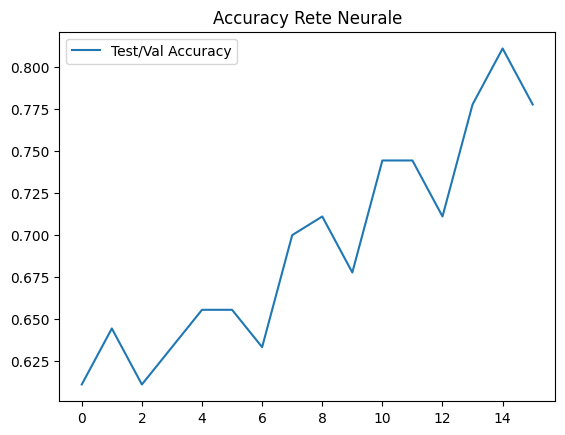


--- SVM ---
Accuracy: 0.7667 | Loss: 0.5385
Matrice di Confusione:
 [[45 10]
 [11 24]]

--- RETE NEURALE ---
Accuracy: 0.8111 | Loss: 0.5213
Matrice di Confusione:
 [[46  9]
 [ 8 27]]


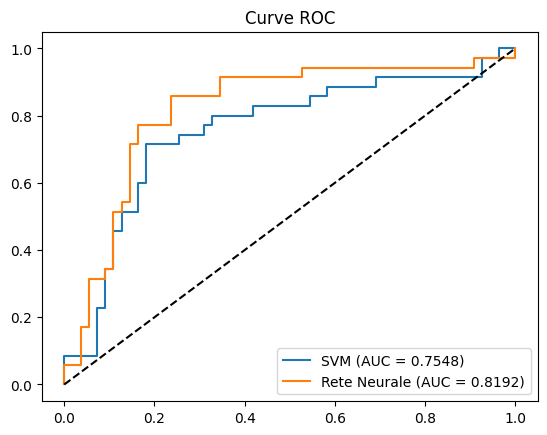

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, log_loss, roc_curve, auc
import torch
import torch.nn.functional as F

# Grafico Accuracy
plt.plot(val_acc_history, label='Test/Val Accuracy')
# Aggiungi plt.plot(train_acc_history, label='Train') se l'hai salvata nel ciclo precedente
plt.title('Accuracy Rete Neurale')
plt.legend()
plt.show()

# Predizioni (Metodo ultra-veloce senza DataLoader)
# SVM
svm_preds = best_svm.predict(X_val_sel)
svm_probs = best_svm.predict_proba(X_val_sel)[:, 1] 

# Rete Neurale
best_model.eval()
with torch.no_grad():
    # Passiamo tutto il validation set in un colpo solo
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
    out = best_model(X_val_tensor)
    
    nn_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    nn_preds = out.argmax(dim=1).cpu().numpy()

# Metriche e Matrici di Confusione 
def stampa_metriche(nome, y_true, y_pred, y_prob):
    print(f"\n--- {nome} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f} | Loss: {log_loss(y_true, y_prob):.4f}")
    print("Matrice di Confusione:\n", confusion_matrix(y_true, y_pred))

stampa_metriche("SVM", y_val, svm_preds, svm_probs)
stampa_metriche("RETE NEURALE", y_val, nn_preds, nn_probs)

# Curve ROC e AUC 
fpr_svm, tpr_svm, _ = roc_curve(y_val, svm_probs)
fpr_nn, tpr_nn, _ = roc_curve(y_val, nn_probs)

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.4f})')
plt.plot(fpr_nn, tpr_nn, label=f'Rete Neurale (AUC = {auc(fpr_nn, tpr_nn):.4f})')
plt.plot([0, 1], [0, 1], 'k--') # Linea casuale di riferimento
plt.title('Curve ROC')
plt.legend()
plt.show()